## <u>Import Libraries</u>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torchvision
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

/opt/anaconda3/envs/pytorch/lib/python3.10/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/opt/anaconda3/envs/pytorch/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <0B7EB158-53DC-3403-8A49-22178CAB4612> /opt/anaconda3/envs/pytorch/lib/python3.10/site-packages/torchvision/image.so
  Reason: tried: '/opt/anaconda3/envs/pytorch/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/pytorch/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/pytorch/lib/python3.10/lib-dynload/../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/pytorch/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `li

---
## <u>Image Transformations & Load Dataset</u>

Same transform as the RNN build: MNIST is grayscale (1 channel, not 3), so `Normalize` takes one mean/std pair, `(0.1307,)` and `(0.3081,)`, its real known statistics rather than a generic placeholder.

`torchvision.datasets.MNIST` auto downloads on first run.

In [2]:
transformations = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_set = MNIST("../dataset", train=True, download=True, transform=transformations)
test_set = MNIST("../dataset", train=False, download=True, transform=transformations)

---
## <u>Train, Validation, Test Split</u>

Every prior notebook we built used only `train_loader` and `test_loader`, with `test_loader` doing two jobs at once: deciding which epoch's weights to checkpoint (`best_val_loss`), and then reporting the final accuracy. That is a real, if subtle, leakage problem: the test set was helping choose the model before being used to grade it, so the final reported number ends up slightly optimistic, not a fully honest measure of generalization to truly unseen data. Not leakage into the model's weights (`test_loader` never touches `.backward()` or `optimizer.step()`), but leakage into the reported result.

The fix: split `train_set` itself into a real training portion and a validation portion. Validation, carved out of training data, is what decides checkpointing during the loop. The genuine `test_set` (MNIST's separate 10,000 image holdout, `train=False`) is touched exactly once, after training is completely finished, purely to report the final number, never to make any decision along the way.

In [3]:
# splitting train_set itself into a training portion and a validation portion
# validation is what decides checkpointing during training, not the real test set
# generator with a fixed seed keeps the split reproducible, same convention as random_state=42 elsewhere
train_subset, val_subset = torch.utils.data.random_split(
    train_set,
    [0.9, 0.1],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)  # carved from training data, used for checkpointing
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)   # untouched until final evaluation, used exactly once

---
## <u>Model Architecture</u>

Same row as timestep idea as the RNN build: a 28x28 image is read as a sequence of 28 rows, `sequence_length = 28`, `input_size = 28` pixels per row. No `nn.Embedding` layer, pixel values are already numbers, nothing to look up.

**Hidden state vs cell state, the part that differs from plain RNN:** LSTM tracks two things across the sequence instead of one.

The cell state is the long term memory, the conveyor belt. It runs through the whole sequence mostly undisturbed, only edited by the forget gate and input gate at each step. It is what lets LSTM carry information across many timesteps without it decaying, the actual fix for the vanishing gradient problem.

The hidden state is the short term, filtered output at each step, what the output gate decides is worth revealing right now from the cell state. It is the hidden state, not the cell state, that a many to one classifier should read from, because the hidden state is specifically the gated, filtered summary meant to be handed onward. The cell state is internal bookkeeping, not designed to be read directly by a downstream layer.

Shape journey (batch_size=128, hidden_size=128, num_layers=1):
```
(128, 1, 28, 28)         128 images, 1 channel, 28x28 pixels
      |
      | x.squeeze(1)
      v
(128, 28, 28)             128 images, 28 rows each, 28 pixels per row, goes into the LSTM
      |
      | self.lstm(x, (h0, c0)), h0 and c0 each shape (1, 128, 128)
      v
out: (128, 28, 128)        hidden state at every one of the 28 row timesteps
hn:  (1, 128, 128)          hidden state at only the final row, this is what gets kept
cn:  (1, 128, 128)           cell state at the final row, captured but not passed to fc
      |
      | hn[-1]
      v
(128, 128)                    last layer's final hidden state, the model's summary of the whole image
      |
      | dropout(0.3), then self.fc: Linear(128 -> 10)
      v
(128, 10)                       10 raw class scores per image
```

In [4]:
class LSTM(nn.Module):

    def __init__(self, input_size=28, hidden_size=128, num_layers=1, num_classes=10):
        super(LSTM, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.num_classes = num_classes

        # no embedding layer, pixels are already numbers, nothing to look up
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        # 10 output neurons, one score per digit 0 to 9
        # dropout sits right before the final linear layer, same spot as every prior build
        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):

        # (batch, 1, 28, 28) -> (batch, 28, 28), dropping the grayscale channel the lstm does not need
        x_reshaped = x.squeeze(1)

        # blank starting hidden state and cell state, both (num_layers, batch_size, hidden_size)
        hidden_state_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        cell_state_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        # lstm reads the image 28 rows at a time, returns per timestep history (unused) and the final (hidden, cell) pair
        hidden_state_history, (final_hidden_state, final_cell_state) = self.lstm(x_reshaped, (hidden_state_0, cell_state_0))

        # fc reads the final HIDDEN state, not the cell state, [-1] drops the num_layers dimension
        x_fc = self.fc(final_hidden_state[-1])

        return x_fc

---
## <u>Compile the Model</u>

In [5]:
input_size = 28

model = LSTM(input_size)

loss_func = nn.CrossEntropyLoss()  # multiclass, applies softmax internally
optimizer = optim.Adam(model.parameters())

---
## <u>Train the Model</u>

Same skeleton as the RNN and sentiment LSTM builds: outer epoch loop, `model.train()`/`model.eval()`, the five step batch sequence, checkpoint on best validation loss. `y_batch` is already plain integer class labels straight from `MNIST`, no reshaping needed.

The validation half of the loop runs over `val_loader`, carved out of training data. `test_loader` does not appear anywhere in this cell.

In [6]:
epochs = 20

train_loss_history = []
val_loss_history = []
best_val_loss = float("inf")
best_epoch = 1

for epoch in range(epochs):
    model.train()
    total_train_loss = 0.0

    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred_tensors = model(x_batch)
        batch_loss = loss_func(y_pred_tensors, y_batch)
        batch_loss.backward()
        optimizer.step()

        total_train_loss = total_train_loss + batch_loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:  # validation set, carved from training data, not the real test set
            y_pred_tensors = model(x_batch)
            batch_loss = loss_func(y_pred_tensors, y_batch)

            total_val_loss = total_val_loss + batch_loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_loss_history.append(avg_val_loss)

    print(f"epoch = {epoch + 1}/{epochs} -----------> train loss = {avg_train_loss} -----------> validation loss = {avg_val_loss}")

    if best_val_loss > avg_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_lstm_model.pt")

print("best model at epoch : ", best_epoch)

epoch = 1/20 -----------> train loss = 0.5575754624124952 -----------> validation loss = 0.16552199783952945
epoch = 2/20 -----------> train loss = 0.13236496575459203 -----------> validation loss = 0.09931825585861473
epoch = 3/20 -----------> train loss = 0.08964479046816368 -----------> validation loss = 0.08519652347139856
epoch = 4/20 -----------> train loss = 0.06614546550181805 -----------> validation loss = 0.07413274186484992
epoch = 5/20 -----------> train loss = 0.05594609343883762 -----------> validation loss = 0.07460090296065554
epoch = 6/20 -----------> train loss = 0.04682558589952587 -----------> validation loss = 0.06580780326150992
epoch = 7/20 -----------> train loss = 0.04236623202616093 -----------> validation loss = 0.056514616057455065
epoch = 8/20 -----------> train loss = 0.03803493114634113 -----------> validation loss = 0.05909350227336697
epoch = 9/20 -----------> train loss = 0.03341054580542943 -----------> validation loss = 0.04919153315379245
epoch = 10

---
## <u>Plot the Loss Curves</u>

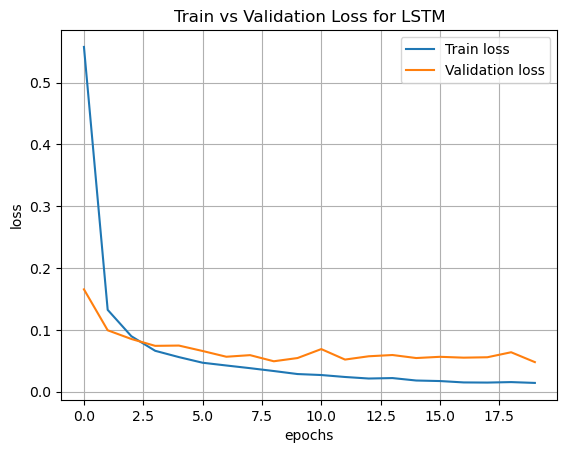

In [7]:
df_loss = pd.DataFrame({
    "Train loss": train_loss_history,
    "Validation loss": val_loss_history
})

plt.plot(df_loss["Train loss"], label="Train loss")
plt.plot(df_loss["Validation loss"], label="Validation loss")

plt.title("Train vs Validation Loss for LSTM")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.grid(True)
plt.legend()
plt.show()

---
## <u>Load Best Checkpoint</u>

In [8]:
model.load_state_dict(torch.load("best_lstm_model.pt", weights_only=True))

<All keys matched successfully>

---
## <u>Evaluate</u>

Same batch accumulated pattern as the RNN build: loop over each loader, collect predictions and labels batch by batch, `torch.cat` together, compute metrics once on the full set. `dim=1` in `argmax` searches across each image's 10 class scores, not across the batch, giving one predicted digit per image. `average='weighted'` since this is multiclass, 10 digits.

`test_loader` appears only here, used exactly once, after training and checkpoint selection are both finished. The testing numbers below are the honest measure of generalization.

In [9]:
model.eval()

all_train_preds = []
all_train_labels = []
all_test_preds = []
all_test_labels = []

with torch.no_grad():
    for x_train_batch, y_train_batch in train_loader:

        y_train_pred_tensor = model(x_train_batch)
        predicted_train_classes = torch.argmax(y_train_pred_tensor, dim=1)

        all_train_preds.append(predicted_train_classes)
        all_train_labels.append(y_train_batch)

    for x_test_batch, y_test_batch in test_loader:  # untouched until now

        y_test_pred_tensor = model(x_test_batch)
        predicted_test_classes = torch.argmax(y_test_pred_tensor, dim=1)

        all_test_preds.append(predicted_test_classes)
        all_test_labels.append(y_test_batch)

all_train_preds = torch.cat(all_train_preds)
all_train_labels = torch.cat(all_train_labels)
all_test_preds = torch.cat(all_test_preds)
all_test_labels = torch.cat(all_test_labels)

print("For Training:")
print(f"Accuracy Score : {accuracy_score(all_train_labels.numpy(), all_train_preds.numpy())}")
print(f"Precision Score : {precision_score(all_train_labels.numpy(), all_train_preds.numpy(), average='weighted')}")
print(f"Recall Score : {recall_score(all_train_labels.numpy(), all_train_preds.numpy(), average='weighted')}")
print(f"F1 Score : {f1_score(all_train_labels.numpy(), all_train_preds.numpy(), average='weighted')}")
print("\n")
print("For Testing:")
print(f"Accuracy Score : {accuracy_score(all_test_labels.numpy(), all_test_preds.numpy())}")
print(f"Precision Score : {precision_score(all_test_labels.numpy(), all_test_preds.numpy(), average='weighted')}")
print(f"Recall Score : {recall_score(all_test_labels.numpy(), all_test_preds.numpy(), average='weighted')}")
print(f"F1 Score : {f1_score(all_test_labels.numpy(), all_test_preds.numpy(), average='weighted')}")

For Training:
Accuracy Score : 0.9974814814814815
Precision Score : 0.9974895931410915
Recall Score : 0.9974814814814815
F1 Score : 0.9974819854227528


For Testing:
Accuracy Score : 0.9868
Precision Score : 0.9868372798529601
Recall Score : 0.9868
F1 Score : 0.9867954010311177
